In [1]:
# importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Mounting Data
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Set options to display the entire DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


In [36]:
file_path = '/content/drive/MyDrive/Machine Learning Lab/wine+quality/winequality-white.csv'

df_white = pd.read_csv(file_path, delimiter=';')
print("Dataset loaded successfully!")
print(df_white.head())

Dataset loaded successfully!
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5   

In [37]:
file_path = '/content/drive/MyDrive/Machine Learning Lab/wine+quality/winequality-red.csv'

df_red = pd.read_csv(file_path, delimiter=';')
print("Dataset loaded successfully!")
print(df_red.head())

Dataset loaded successfully!
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8   

In [10]:
# For viewing in Google Sheets
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_red)

https://docs.google.com/spreadsheets/d/1beJhN20ghrWIsLTpH2MDTot7iyOCXZFTnzEuXM8lqG4/edit#gid=0


In [58]:
X = df_red.iloc[:, :-1].values
y = df_red.iloc[:, -1].values

In [13]:
X = df_white.iloc[:, :-1].values
y = df_white.iloc[:, -1].values

In [14]:
# Viewing Null fields as T/F
df_red.isnull()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [15]:
# Viewing Null fields as T/F
df_white.isnull()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [16]:
# Total Number of Null values in each field
df_red.isnull().sum()


,0
"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality""",0


In [17]:
# Total Number of Null values in each field
df_white.isnull().sum()

,0
"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality""",0


In [18]:
# Checking if duplicate values are present or not
df_red.duplicated().sum()


np.int64(240)

In [19]:
# Checking if duplicate values are present or not
df_white.duplicated().sum()


np.int64(937)

In [20]:
# Checking if there is any missing value in a row
df_red[df_red.isnull().any(axis=1)]


,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""


In [21]:
# Checking if there is any missing value in a row
df_white[df_white.isnull().any(axis=1)]

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""


## There is no missing values available in the datasets (winequality-red.csv & winequality-white.csv)

In [22]:
# Cleaning dataset by removing duplicate entries & Checking again
df_red = df_red.drop_duplicates()
df_red.duplicated().sum()

np.int64(0)

In [23]:
# Cleaning dataset by removing duplicate entries & Checking again
df_white = df_white.drop_duplicates()
df_white.duplicated().sum()

np.int64(0)

In [24]:
from sklearn.model_selection import train_test_split

In [41]:
X = df_red.drop("quality",axis=1) # Removing the target(label) column
y = df_red["quality"] # Contains the labels

X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=62
)
# 20% for testing 80% for training
# Random state for same split every time

In [39]:
X = df_white.drop('quality', axis=1)
y = df_white['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=62
)
# 20% for testing 80% for training
# Random state for same split every time

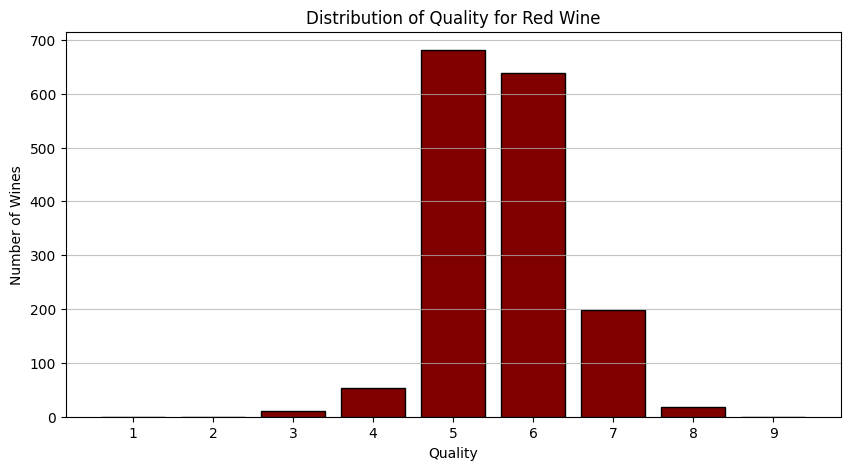

In [42]:
plt.figure(figsize=(10, 5))
plt.hist(df_red['quality'], bins=range(1, 11), align='left', rwidth=0.8, color='maroon', edgecolor='black')
plt.title('Distribution of Quality for Red Wine')
plt.xlabel('Quality')
plt.ylabel('Number of Wines')
plt.xticks(range(1, 10))
plt.grid(axis='y', alpha=0.75)
plt.show()

# Histogram

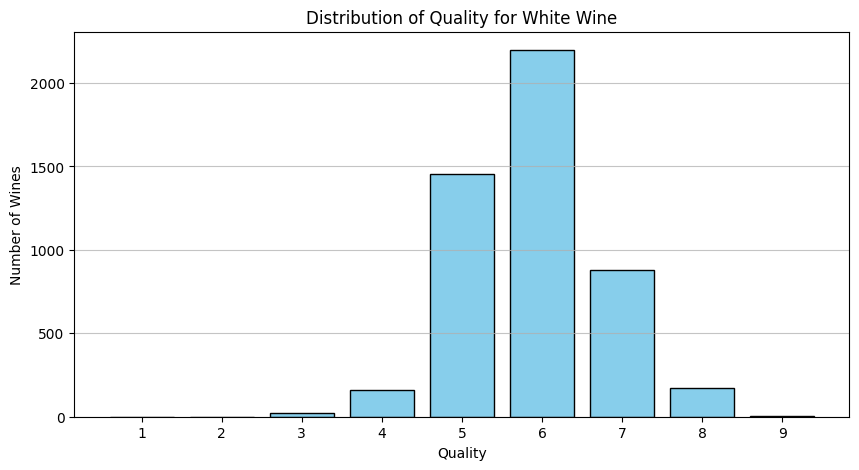

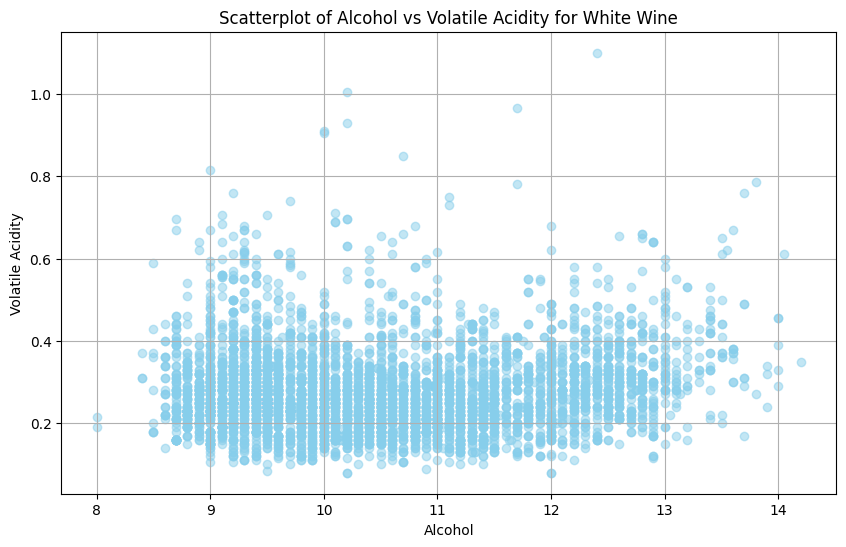

In [45]:
plt.figure(figsize=(10, 5))
plt.hist(df_white['quality'], bins=range(1, 11), align='left', rwidth=0.8, color='skyblue', edgecolor='black')
plt.title('Distribution of Quality for White Wine')
plt.xlabel('Quality')
plt.ylabel('Number of Wines')
plt.xticks(range(1, 10))
plt.grid(axis='y', alpha=0.75)
plt.show()
print("\n")
# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df_white['alcohol'], df_white['volatile acidity'], alpha=0.5, color='skyblue')
plt.title('Scatterplot of Alcohol vs Volatile Acidity for White Wine')
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.grid(True)
plt.show()

In [55]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler_white = StandardScaler()

# Scale the training and testing data for white wine
X_train_white_scaled = scaler_white.fit_transform(X_train)
X_test_white_scaled = scaler_white.transform(X_test)

print("White wine data scaled successfully!")

White wine data scaled successfully!


In [56]:
# Train a Logistic Regression model on the SCALED white wine data
model_white_scaled = LogisticRegression(max_iter=1000, random_state=62)
model_white_scaled.fit(X_train_white_scaled, y_train)

# Make predictions on the scaled test set for white wine
y_pred_white_scaled = model_white_scaled.predict(X_test_white_scaled)

# Calculate accuracy with scaled data for white wine
accuracy_white_scaled = accuracy_score(y_test, y_pred_white_scaled)
print(f"Accuracy for White Wine Classification (Scaled Data): {accuracy_white_scaled:.4f}")

Accuracy for White Wine Classification (Scaled Data): 0.6281


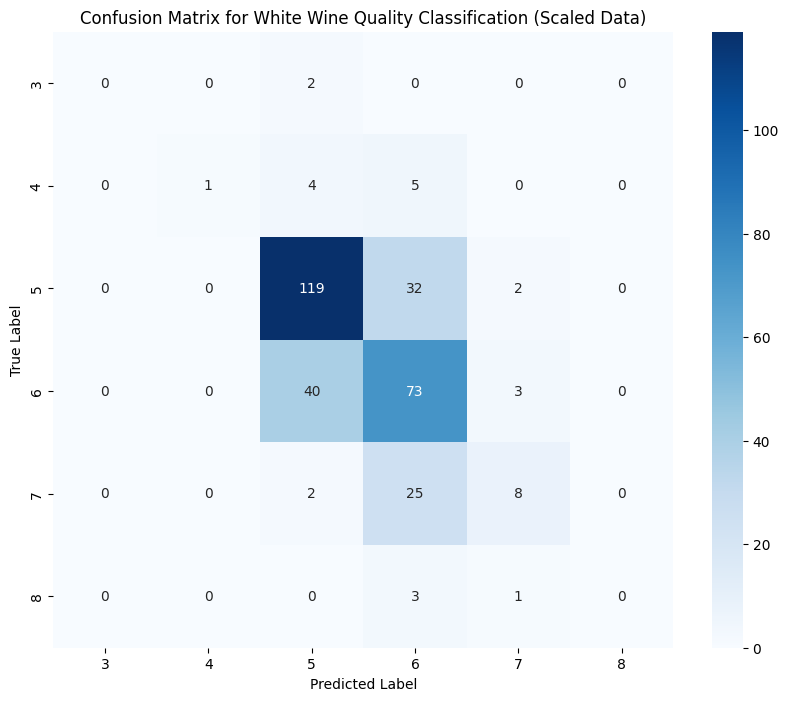

In [57]:
# Generate the confusion matrix for scaled white wine data
cm_white_scaled = confusion_matrix(y_test, y_pred_white_scaled)

# Plot the confusion matrix as a heatmap for scaled white wine data
plt.figure(figsize=(10, 8))
sns.heatmap(cm_white_scaled, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for White Wine Quality Classification (Scaled Data)')
plt.show()

In [49]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully!")

Data scaled successfully!


In [50]:
# Train a Logistic Regression model on the SCALED red wine data
model_red_scaled = LogisticRegression(max_iter=1000, random_state=62)
model_red_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_red_scaled = model_red_scaled.predict(X_test_scaled)

# Calculate accuracy with scaled data
accuracy_red_scaled = accuracy_score(y_test, y_pred_red_scaled)
print(f"Accuracy for Red Wine Classification (Scaled Data): {accuracy_red_scaled:.4f}")

Accuracy for Red Wine Classification (Scaled Data): 0.6281


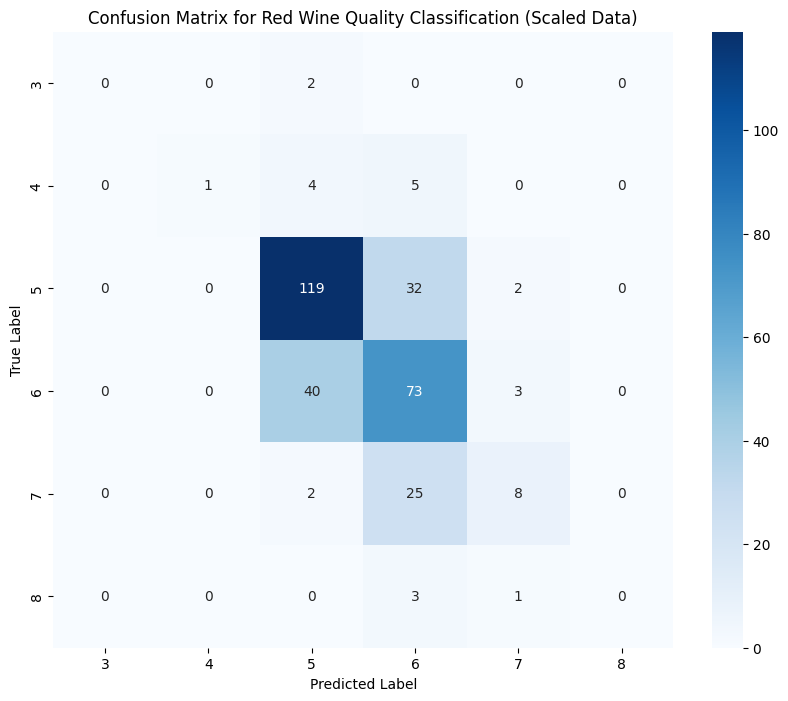

In [51]:
# Generate the confusion matrix for scaled data
cm_red_scaled = confusion_matrix(y_test, y_pred_red_scaled)

# Plot the confusion matrix as a heatmap for scaled data
plt.figure(figsize=(10, 8))
sns.heatmap(cm_red_scaled, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Red Wine Quality Classification (Scaled Data)')
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully!")

Data scaled successfully!


In [53]:
# Train a Logistic Regression model on the SCALED red wine data
model_red_scaled = LogisticRegression(max_iter=1000, random_state=62)
model_red_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_red_scaled = model_red_scaled.predict(X_test_scaled)

# Calculate accuracy with scaled data
accuracy_red_scaled = accuracy_score(y_test, y_pred_red_scaled)
print(f"Accuracy for Red Wine Classification (Scaled Data): {accuracy_red_scaled:.4f}")

Accuracy for Red Wine Classification (Scaled Data): 0.6281


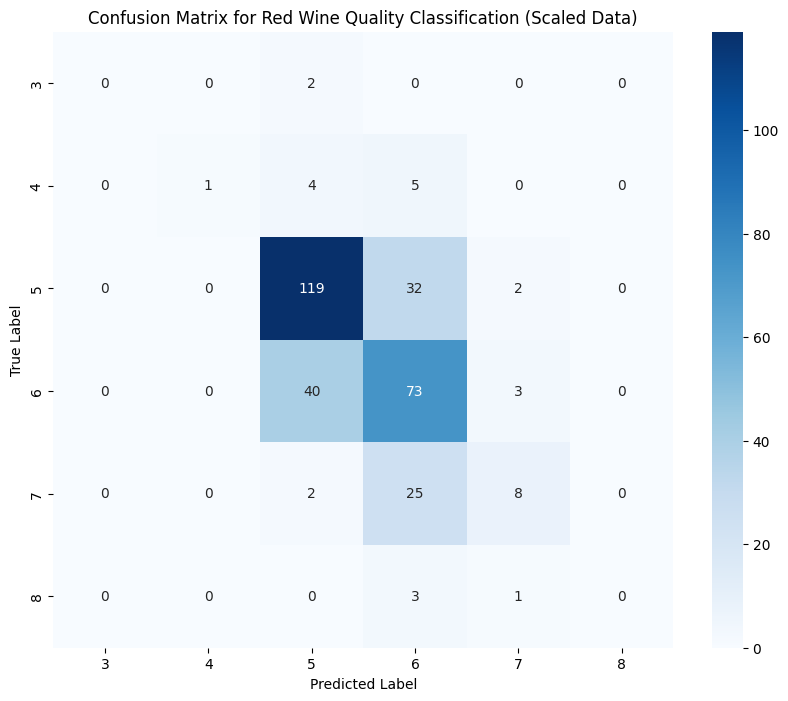

In [54]:
# Generate the confusion matrix for scaled data
cm_red_scaled = confusion_matrix(y_test, y_pred_red_scaled)

# Plot the confusion matrix as a heatmap for scaled data
plt.figure(figsize=(10, 8))
sns.heatmap(cm_red_scaled, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Red Wine Quality Classification (Scaled Data)')
plt.show()

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

In [47]:
# Train a Logistic Regression model on the red wine data
model_red = LogisticRegression(max_iter=1000, random_state=62) # Increased max_iter for convergence
model_red.fit(X_train, y_train)

# Make predictions on the test set
y_pred_red = model_red.predict(X_test)

# Calculate accuracy
accuracy_red = accuracy_score(y_test, y_pred_red)
print(f"Accuracy for Red Wine Classification: {accuracy_red:.4f}")

Accuracy for Red Wine Classification: 0.6250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


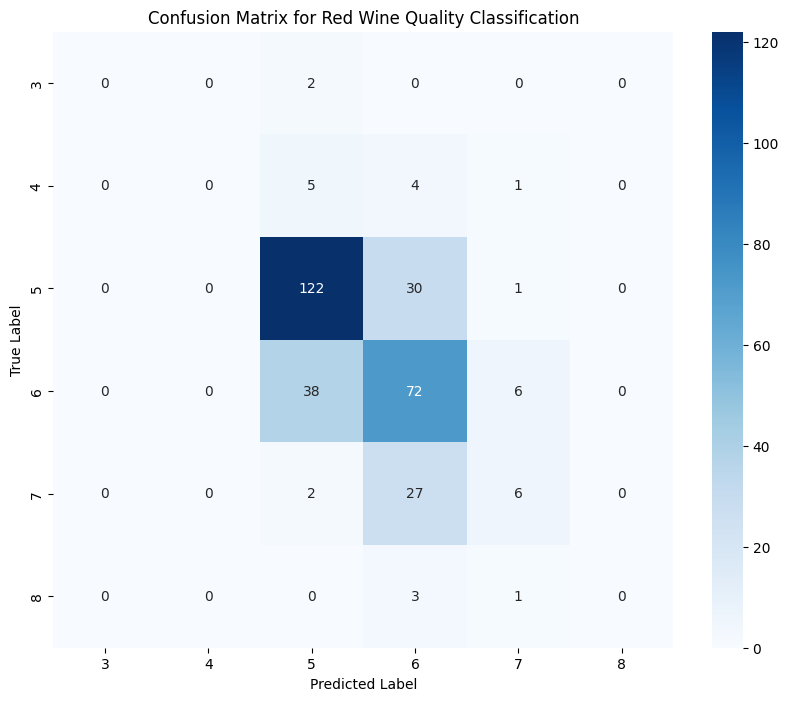

In [48]:
# Generate the confusion matrix
cm_red = confusion_matrix(y_test, y_pred_red)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_red, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Red Wine Quality Classification')
plt.show()